# 实践：艺术二维码

## 本项目需要使用到以下库：
## - opencv-python
## - pyzbar
## - numpy
## - matplotlib
## - qrcode

## 安装这些库可以使用pip命令，在Anaconda Prompt中输入以下命令：

```
pip install opencv-python pyzbar numpy matplotlib qrcode
```



In [14]:
# 导入必要的库
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 生成二维码
import qrcode

# 二维码解码
from pyzbar.pyzbar import decode


# 生成简单的二维码

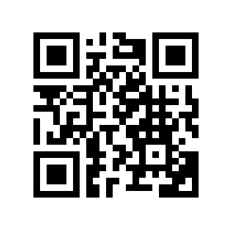

In [15]:

# 创建二维码实例，可以设置版本， 错误纠正， 大小，边框等
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)

# 二维码内容
data = "https://www.baidu.com"
qr.add_data(data)

# 生成二维码图片，填充颜色，背景颜色，并保存
qr.make(fit=True)
img = qr.make_image(fill_color="black", back_color="white")
# 生成二维码图片路径和文件名，默认当前路径
QRImgPath="1_qrcode.png"
img.save(QRImgPath)

# 弹出窗口显示二维码图片
# img.show()


# 读取二维码图片，并显示
code_img = cv2.imread(QRImgPath, 1)
reversed_channels = code_img[:, :, [2, 1, 0]]  # RGB顺序
plt.axis("off")
plt.imshow(reversed_channels)



# 生成带有自己logo和自定义信息的二维码

二维码已保存至：1_Art_qrcode.png


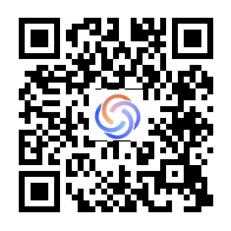

In [16]:
import cv2
import numpy as np
import qrcode
import matplotlib.pyplot as plt

# ------------------ 生成二维码 ------------------
text = "https://www.hitwh.edu.cn"

qr = qrcode.QRCode(
    version=4,  # 控制二维码尺寸(1-40)
    error_correction=qrcode.constants.ERROR_CORRECT_H,  # 30%容错率
    box_size=10,
    border=2,
)
qr.add_data(text)
qr.make(fit=True)

# 生成二维码图像（黑白）并转换为OpenCV格式
qr_img = qr.make_image(fill_color="black", back_color="white").convert('RGB')
qr_img = np.array(qr_img)  # 转为numpy数组
qr_img = cv2.cvtColor(qr_img, cv2.COLOR_RGB2BGR)

# ------------------ 读取Logo并嵌入 ------------------
logo_path = "images/logo.png"
logo = cv2.imread(logo_path, cv2.IMREAD_UNCHANGED)  # 保留alpha通道
if logo is None:
    raise FileNotFoundError(f"Logo文件未找到: {logo_path}")

# 调整Logo大小（不超过二维码1/4）
qr_h, qr_w = qr_img.shape[:2]
logo_size = min(qr_w, qr_h) // 4
logo_h, logo_w = logo.shape[:2]
scale = logo_size / max(logo_w, logo_h)
logo = cv2.resize(logo, (int(logo_w * scale), int(logo_h * scale)), interpolation=cv2.INTER_AREA)

# 计算Logo中心位置
l_h, l_w = logo.shape[:2]
x_offset = (qr_w - l_w) // 2
y_offset = (qr_h - l_h) // 2

# 处理透明通道
if logo.shape[2] == 4:  # 包含alpha通道
    alpha_logo = logo[:, :, 3] / 255.0
    for c in range(3):  # BGR通道
        qr_img[y_offset:y_offset+l_h, x_offset:x_offset+l_w, c] = (
            alpha_logo * logo[:, :, c] + (1 - alpha_logo) * qr_img[y_offset:y_offset+l_h, x_offset:x_offset+l_w, c]
        )
else:  # 没有透明通道直接覆盖
    qr_img[y_offset:y_offset+l_h, x_offset:x_offset+l_w] = logo[:, :, :3]

# ------------------ 保存二维码 ------------------
output_path = "1_Art_qrcode.png"
cv2.imwrite(output_path, qr_img)
print(f"二维码已保存至：{output_path}")

# ------------------ 显示二维码 ------------------
reversed_channels = cv2.cvtColor(qr_img, cv2.COLOR_BGR2RGB)
plt.axis("off")
plt.imshow(reversed_channels)
plt.show()

# 识别二维码,可以同时识别多个二维码并在图像底部显示识别结果

解码成功 -> 二维码#1，类型：QRCODE，内容：http://www.zcool.com.cn/u/13370673
解码成功 -> 二维码#2，类型：QRCODE，内容：http://weixin.qq.com/r/PVeblLjEjYbyh6n3nwIZ
解码成功 -> 二维码#3，类型：QRCODE，内容：http://weibo.cn/qr/userinfo?uid=1236130832
带解析结果的图片已保存为 2_QRcode_Result.png


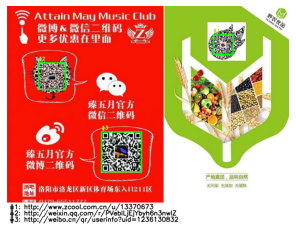

In [17]:
import cv2
import numpy as np
from pyzbar.pyzbar import decode
import matplotlib.pyplot as plt

# 读取的二维码的文件名
# img_path = "art_qrcode.png"
img_path = "images/QRCodeToRead.jpg"

# 写结果图像的文件名
output_path = "2_QRcode_Result.png"

# 读取图像
img = cv2.imread(img_path)
if img is None:
    print(f"错误：无法读取图像文件 {img_path}")
    exit()

# 解码所有二维码
detected = decode(img)
if not detected:
    print("未检测到二维码")
    exit()

# 准备存储内容
contents = []

# 绘制二维码边框并编号
for idx, obj in enumerate(detected, start=1):
    # 获取二维码边界框
    points = obj.polygon
    if len(points) != 4:
        exit("二维码边框不合法")
    pts = np.array(points, dtype=np.int32).reshape((-1, 1, 2))
    cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=3)

    # 在二维码左上角标注编号
    text_pos = (pts[0][0][0], pts[0][0][1] - 10)
    cv2.putText(img, f"#{idx}", text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (64, 218, 192), 2)

    # 解码内容
    try:
        content = obj.data.decode('utf-8')
    except UnicodeDecodeError:
        content = obj.data.decode('latin-1')
    contents.append((idx, content))
    print(f"解码成功 -> 二维码#{idx}，类型：{obj.type}，内容：{content}")

# 准备显示二维码内容的底部区域
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.8
font_thickness = 2
line_height = 24

# 扩展图像底部
rows_to_add = line_height * len(contents) + 10
height, width = img.shape[:2]
extended_img = np.ones((height + rows_to_add, width, 3), dtype=np.uint8) * 255  # 白色背景
extended_img[:height, :, :] = img

# 在底部区域写入二维码编号和内容
for i, (idx, content) in enumerate(contents):
    y_pos = height + (i + 1) * line_height
    cv2.putText(extended_img, f"#{idx}: {content}", (10, y_pos), font, font_scale, (0, 0, 0), font_thickness)

# 保存结果
cv2.imwrite(output_path, extended_img)
print(f"带解析结果的图片已保存为 {output_path}")

# 显示结果
reversed_channels = extended_img[:, :, [2, 1, 0]]  # BGR -> RGB
plt.axis("off")
plt.imshow(reversed_channels)
plt.show()